In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score


X = pd.read_csv("../dataset/j_kampe.csv")
y = pd.read_csv("../dataset/distances.csv")["distance"]

split_idx = int(0.8 * X.shape[0])
split_idy = int(0.8 * y.shape[0])

X_train = X[:split_idx]
X_test  = X[split_idx:]
y_train = y[:split_idy]
y_test  = y[split_idy:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()


In [72]:
def plot_pca(pca,x_tick_min=0,x_tick_step=1):

    nattrib = pca.n_components_
    
    plt.figure()
    plt.plot(pca.explained_variance_ratio_)
    plt.ylabel('Variance')
    plt.xlabel('Principal Component')
    plt.title('Variance per component')
    plt.grid()
    plt.xlim(0,nattrib-1)
    xticks = list(range(x_tick_min,nattrib,x_tick_step))
    #xticks.append(nattrib-1)
    xticks.insert(0,0)
    plt.xticks(ticks=xticks, labels=[str(int(max(i,1))) for i in xticks])

    plt.figure()
    soma = [sum(pca.explained_variance_ratio_[:i+1]) for i in range(nattrib)] 
    plt.plot(soma)
    plt.grid()
    plt.ylabel('Percentage of total variance')
    plt.xlabel('Number of PCs')
    plt.xlim(0,nattrib-1)
    plt.title('Cummulative Variance')
    plt.xticks(ticks=xticks, labels=[str(int(max(i,1))) for i in xticks])

94


(80000, 12)

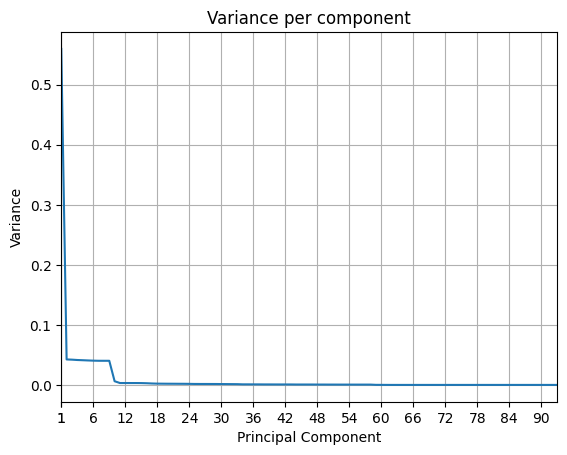

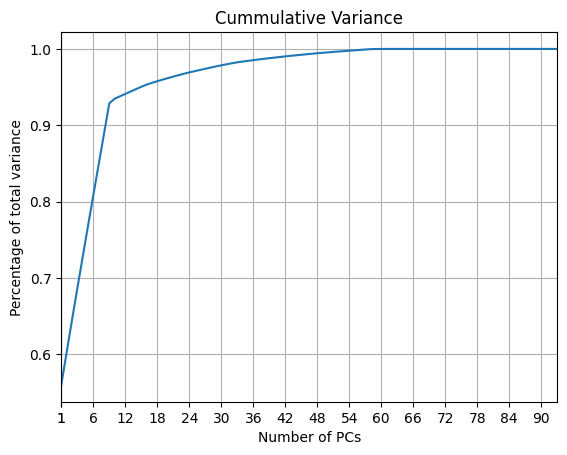

In [73]:
print(X_train.shape[1])
pca_full = PCA(n_components=X_train.shape[1], svd_solver='full').fit(X_train)
plot_pca(pca_full, 0, 6)

pca = PCA(n_components=12, svd_solver='full').fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)


X_train_pca.shape

In [74]:
C_values = (0.1, 1.0, 10.0)
epsilon_values = (0.01, 0.1, 1, 0.02)
best_results = []
best_rmse = np.inf
best_r2   = -np.inf
best_result = None

for C in C_values:
    for epsilon in epsilon_values:
        model = SVR(kernel="rbf", C=C, epsilon=epsilon)
        model.fit(X_train_pca, y_train)
        y_pred_scaled = model.predict(X_test_pca)

        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
        y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))

        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        if rmse < best_rmse and r2 > best_r2:
            best_rmse = rmse
            best_r2 = r2
            best_result = {
                "Best RMSE": rmse,
                "R2": r2,
                "Best C": C,
                "Best Epsilon": epsilon,
            }

df_best = pd.DataFrame([best_result]).sort_values("Best RMSE").reset_index(drop=True)
print(df_best)
df_best.to_csv("../results/svr_pca.csv", index=False)

   Best RMSE        R2  Best C  Best Epsilon
0   0.249012 -0.337167     0.1          0.01


In [ ]:
print(X_train_pca.shape)

(80000, 94)
